# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


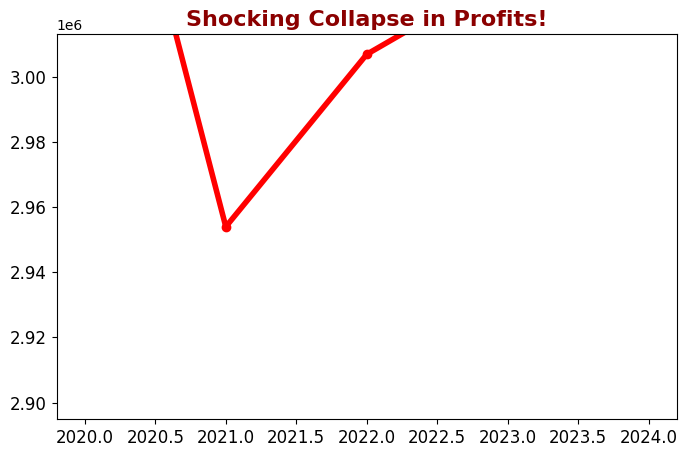

In [2]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

# Wrong variable for title, truncated y-axis, misleading color & framing
plt.plot(subset["Year"], subset["Sales"], color="red", linewidth=4, marker="o")
plt.ylim(subset["Sales"].min() * 0.98, subset["Sales"].min() * 1.02)  # extreme truncation
plt.title("Shocking Collapse in Profits!", fontsize=16, fontweight="bold", color="darkred")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


### Write your notes about bad chart #1 here:
From my initial inspection, I noticed that the years are stored as float data types when they would be more appropriately represented as integers, since years should be whole numbers. Additionally, the line graph does not appear to be displaying the data correctly, as the information seems to be unsorted. Based on the title indicating that the line should decrease over time, this suggests the data may not have been organised properly before plotting. I also noticed that the graph is missing labels for both the x-axis and y-axis, which makes it more difficult to interpret the data clearly.

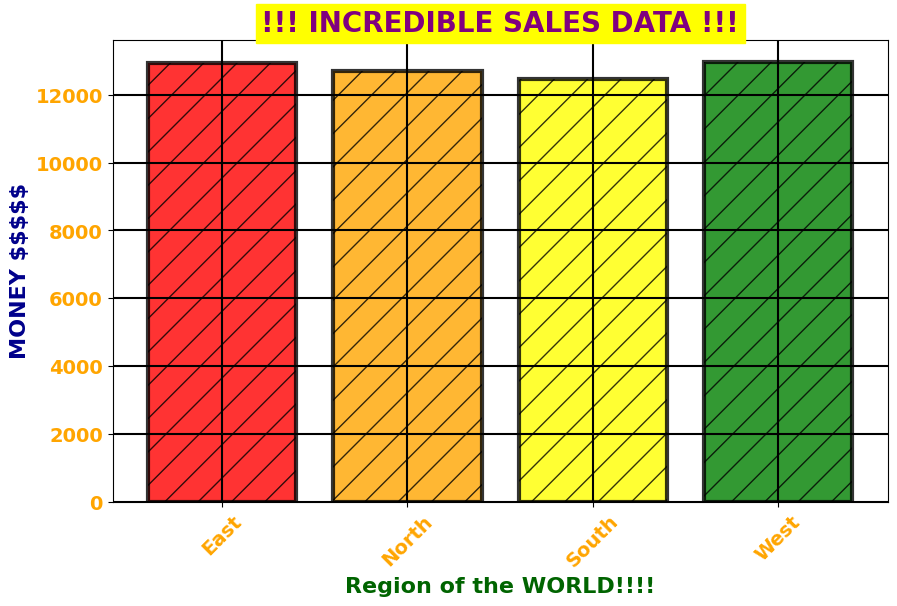

In [3]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["red","orange","yellow","green","blue","purple"]

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=3, hatch="/", alpha=0.8)
plt.title("!!! INCREDIBLE SALES DATA !!!", fontsize=20, fontweight="bold", color="purple", backgroundcolor="yellow")
plt.grid(True, which='both', color='black', linestyle='-', linewidth=1.5)
plt.xlabel("Region of the WORLD!!!!", fontsize=16, fontweight="bold", color="darkgreen")
plt.ylabel("MONEY $$$$$", fontsize=16, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=14, fontweight="bold", color="orange")
plt.yticks(fontsize=14, fontweight="bold", color="orange")
plt.show()


### Write your notes about bad chart #2 here:
The title is very sensationalised and seems designed to make the data appear more exciting than it actually is. The axis labels are also vague, as “MONEY $$$$$” does not explain the units or currency being used, and “Region of the WORLD!!!!” feels exaggerated and unclear. There is also a lot of unnecessary visual clutter, such as the bright colours, patterns, bold text, and heavy gridlines, which distract from the data itself. In addition, the chart does not include a data source or any real context about what the figures represent, making it harder to judge the reliability and meaning of the information.

## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


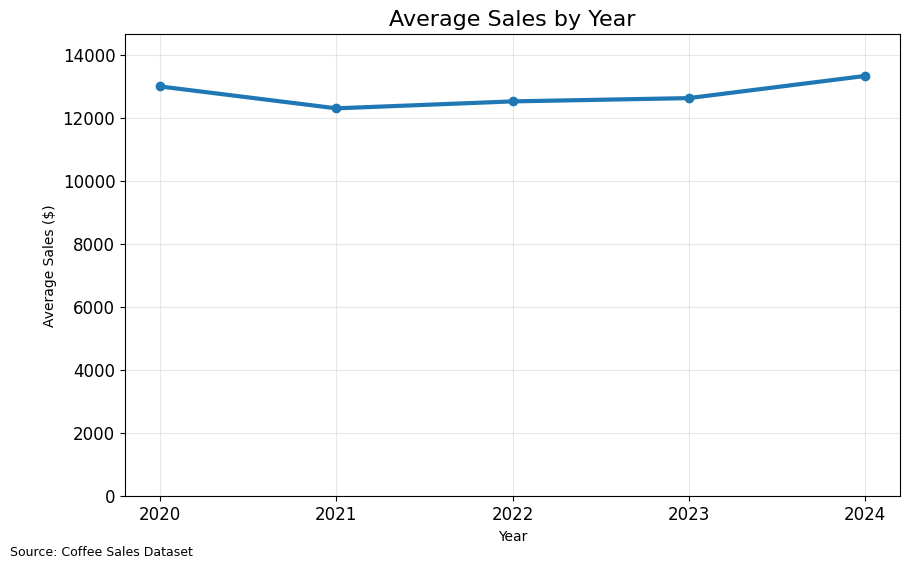

dtype('int64')

In [10]:
# Your GOOD visualization(s) here
plt.figure(figsize=(10,6))
coffee_df["Year"] = coffee_df["Year"].astype(int)


subset = coffee_df.groupby("Year")["Sales"].mean().sort_index()





plt.plot(subset.index, subset.values, linewidth=3, marker="o")
plt.xticks(subset.index.astype(int))

plt.ylim(0, subset.max() * 1.1)
plt.title("Average Sales by Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Average Sales ($)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3)

plt.figtext(0.01, 0.01, "Source: Coffee Sales Dataset", fontsize=9)

plt.show()
coffee_df["Year"].dtype

I changed the title to make it more neutral and started the y-axis at zero to avoid exaggerating differences in sales. I also formatted the year labels and y-axis values as whole numbers and added clear labels and a data source to improve readability and transparency.  The fonts are also at an appopriate size. 

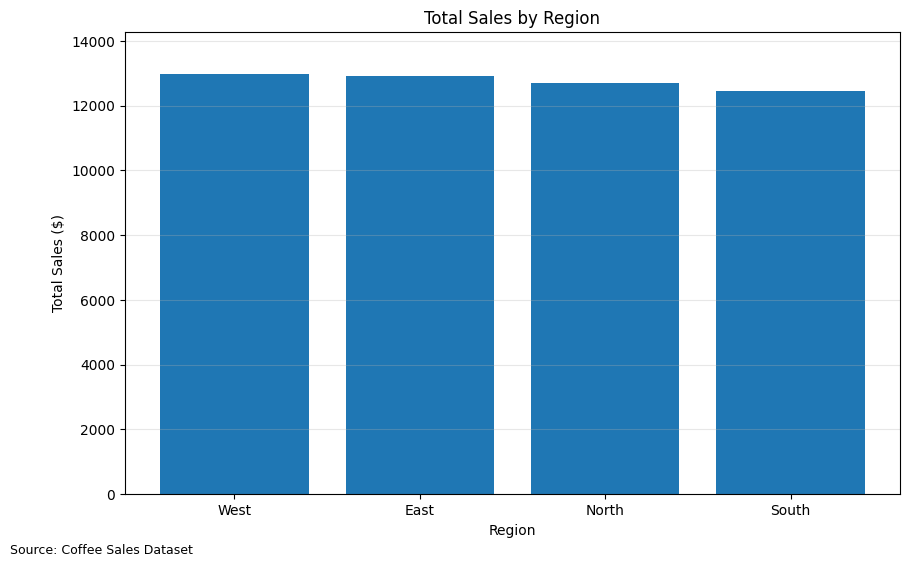

In [13]:

sales_by_region = coffee_df.groupby("Region")["Sales"].mean().sort_values(ascending=False)


plt.figure(figsize=(10,6))
plt.bar(sales_by_region.index, sales_by_region.values)


plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")


plt.ylim(0, sales_by_region.max() * 1.1)


plt.grid(axis='y', alpha=0.3)


plt.figtext(0.01, 0.01, "Source: Coffee Sales Dataset", fontsize=9)

plt.show()


For this chart I removed the bad colors and added the appopriate titles of the X and Y axis. The title is not misleaning anymore and I included a source.  Finally, the y-axis starts at zero